# Predict Loan Default
## Question: Can we predict if a person will default on their loan?


Read the data from the CSV file. 

In [1]:
import pandas as pd

df = pd.read_csv("data/credit_risk_dataset.csv")
df_raw = df.copy()  # Keep raw data just in case 
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.describe() #see what data we have
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


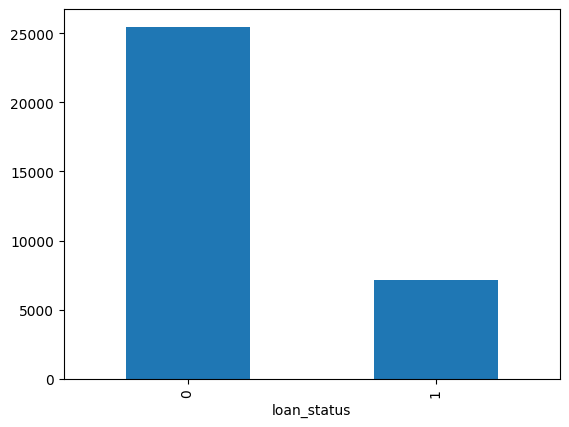

In [3]:
import matplotlib.pyplot as plt
df['loan_status'].value_counts() #target variable to explore 
df['loan_status'].value_counts().plot(kind='bar') #show the bar chart of loan_status 
plt.show()

See if any missing data and do some data cleaning. 

In [4]:
print("The raw data without any modifications: ")
print(df_raw.isna().sum()) #see what data is missing

# person_emp_length and load_int_rate are the only two columns that have missing values. 
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median()) #fill in missing values using the median of the entire dataset 
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median()) #fill in missing values using the median of the entire dataset

print("\nData after filling missing values: ")
print(df.isna().sum()) #see it correctly filled in the data 

The raw data without any modifications: 
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Data after filling missing values: 
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Set the target variable and the predictor variables. 

In [5]:
y = df['loan_status'] # target variable
X = pd.get_dummies(df.drop(columns=['loan_status']), drop_first=True) # one one encoding 

print(X.shape)


(32581, 22)


Split the data into train and test sets. 

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(26064, 22)
(6517, 22)
(26064,)
(6517,)


# Unsupervised Analysis 

## 1) First, we apply PCA to the scaled feature set.   


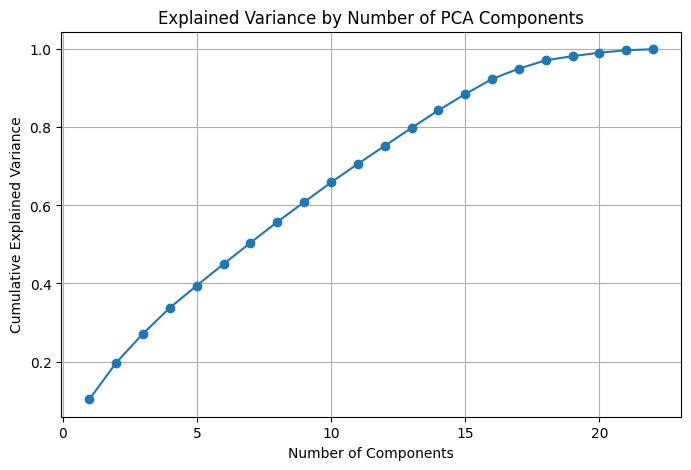

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # scale the training data

# Fit PCA to scaled training data
pca = PCA()
pca.fit(X_train_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.show()

## 2) Explore the distribution of some features

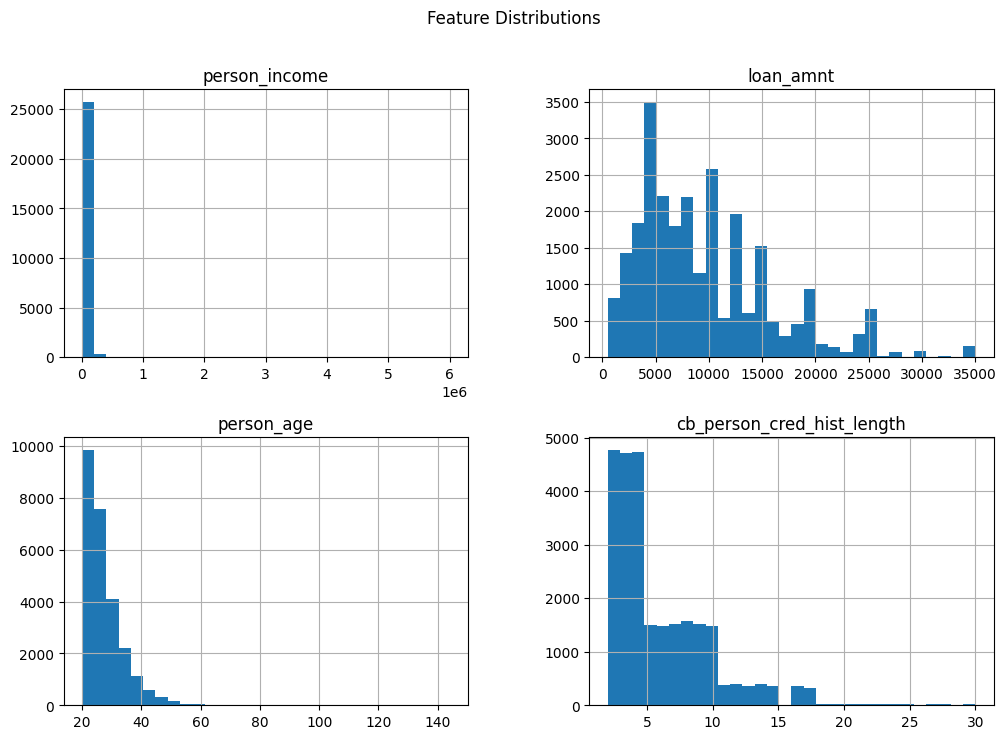

In [ ]:
# Explore person_income, loan_amnt, person_age, and cb_person_cred_hist_length
# to see their distributions
# and plot histograms
X_train.hist(column=['person_income', 'loan_amnt', 'person_age', 'cb_person_cred_hist_length'], bins=30, figsize=(12,8))
plt.suptitle('Feature Distributions')
plt.show()

## 3) Plot the correlation matrix of the features

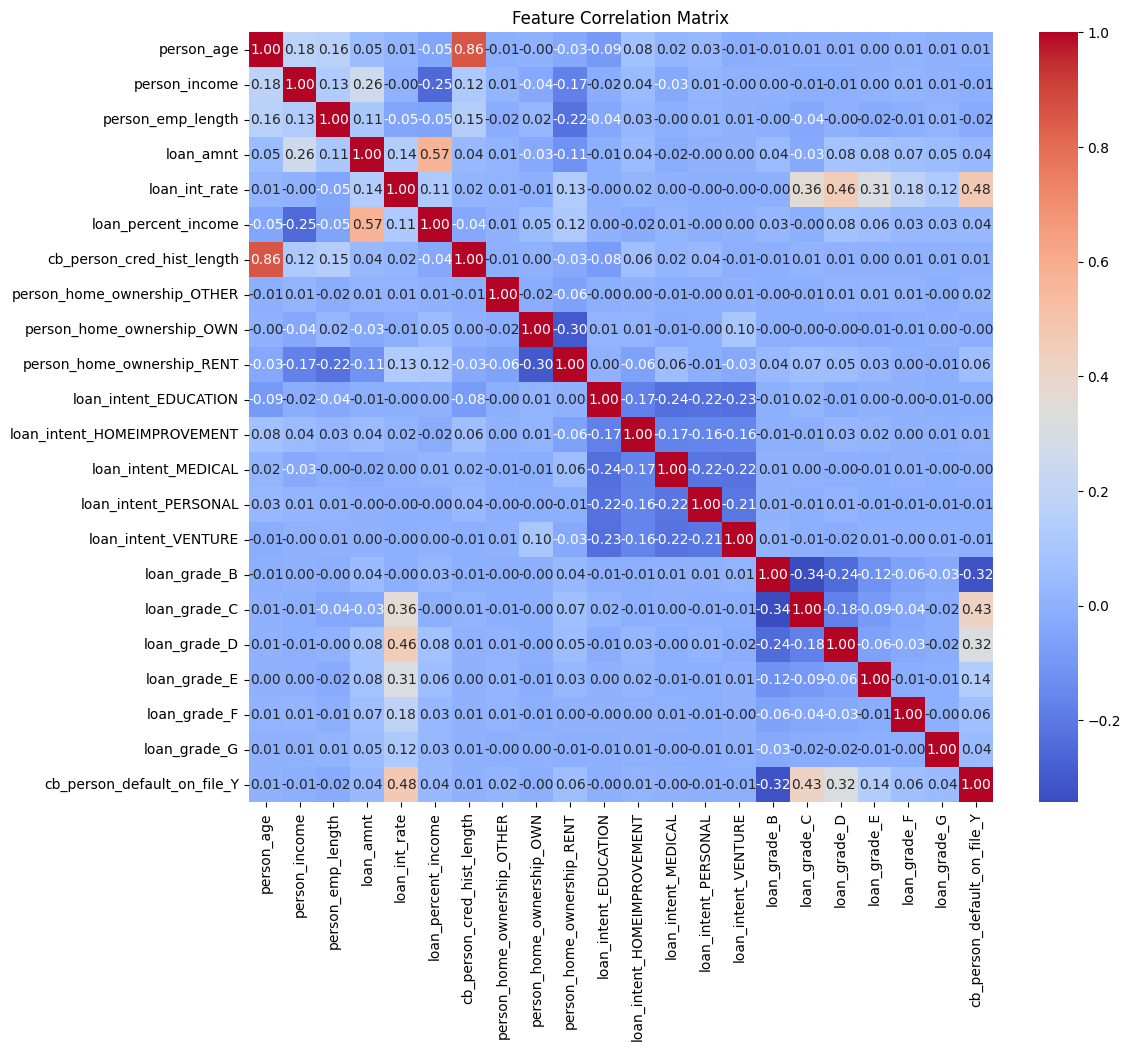

In [37]:
import seaborn as sns

corr_matrix = X_train.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Model 1: Logistic Regression
## Try standardization - scaling transformation

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Try Polynomial Feature Transformation degree = 2


In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features up to degree 2 (includes squares, interactions)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

## Try PCA Feature Transformation 


In [9]:
from sklearn.decomposition import PCA

# Reduce to top N components (say, 10)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Try Interaction-only Features 


In [10]:
poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_inter = poly_interact.fit_transform(X_train_scaled)
X_test_inter = poly_interact.transform(X_test_scaled)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = [] # a list to store the results

#loop through the values of C and fit a logistic regression model on the training set 
def model_evaluation(X_train_t, X_test_t, y_train, y_test, transform_name):

    for val in C_values:
        
        model = LogisticRegression(C = val, max_iter=1000)
        model.fit(X_train_t, y_train)
        y_pred = model.predict(X_test_t)
        
        
        results.append({
            'Transformation': transform_name,
            'regularization parameter C': val,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred)
        })
        
model_evaluation(X_train_scaled, X_test_scaled, y_train, y_test, 'Original')
model_evaluation(X_train_poly, X_test_poly, y_train, y_test, 'Polynomial')
model_evaluation(X_train_pca, X_test_pca, y_train, y_test, 'PCA')
model_evaluation(X_train_inter, X_test_inter, y_train, y_test, 'Interaction Only')


In [18]:
results_df = pd.DataFrame(results)
results_df.head(24)
# results_df.tail(1)
# print(results_df)

,Transformation,regularization parameter C,Accuracy,Precision,Recall,F1 Score
0,Original,0.001,0.851772,0.799750,0.442215,0.569519
1,Original,0.010,0.862667,0.773904,0.537716,0.634545
2,Original,0.100,0.862207,0.766310,0.544637,0.636731
3,Original,1.000,0.861900,0.764820,0.544637,0.636217
4,Original,10.000,0.861900,0.764820,0.544637,0.636217
5,Original,100.000,0.861900,0.764820,0.544637,0.636217
6,Polynomial,0.001,0.895351,0.890481,0.602076,0.718415
7,Polynomial,0.010,0.900414,0.869888,0.647751,0.742562
8,Polynomial,0.100,0.902409,0.868733,0.659516,0.749803
9,Polynomial,1.000,0.902563,0.866184,0.662976,0.751078


# Model 2: Support Vector Machines

In [ ]:
# Model 2: Support Vector Machines
from sklearn.svm import SVC # Support Vector Machines
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #Metrics for evaluation

def evaluate_svm(X_train, X_test, y_train, y_test, transform_name, C_values):
    """
    Train and evaluate an RBF-kernel SVM over multiple regularization parameters.
    Parameters:
        X_train, X_test: feature matrices for training and testing
        y_train, y_test: target vectors for training and testing
        transform_name: name of the feature transformation
        C_values: list of regularization strength values to try
    """
    for C in C_values:
        # Initialize the SVM with RBF kernel and specific C
        svm = SVC(C=C, kernel='rbf', random_state=42)
        # Fit the model on the training data
        svm.fit(X_train, y_train)
        # Predict on the test data
        y_pred = svm.predict(X_test)
        # Compute performance metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=1)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        # Append the results to the shared list
        results.append({
            'Model': 'SVM',
            'Transformation': transform_name,
            'C': C,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1
        })
        # Print a summary for quick feedback
        print(f"SVM ({transform_name}) with C={C}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

# Define regularization values 
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Evaluate SVM on each feature set
evaluate_svm(X_train_scaled, X_test_scaled, y_train, y_test, 'Original', C_values)
evaluate_svm(X_train_poly,   X_test_poly,   y_train, y_test, 'Polynomial', C_values)
evaluate_svm(X_train_pca,    X_test_pca,    y_train, y_test, 'PCA', C_values)
evaluate_svm(X_train_inter,  X_test_inter,  y_train, y_test, 'Interaction Only', C_values)

# Display the SVM results from the combined results list
import pandas as pd
svm_results = pd.DataFrame(results)
svm_results[svm_results['Model'] == 'SVM']

SVM (Original) with C=0.001: Accuracy=0.778, Precision=1.000, Recall=0.000, F1=0.000
SVM (Original) with C=0.01: Accuracy=0.839, Precision=0.798, Recall=0.370, F1=0.505
SVM (Original) with C=0.1: Accuracy=0.893, Precision=0.891, Recall=0.589, F1=0.709
SVM (Original) with C=1: Accuracy=0.908, Precision=0.916, Recall=0.644, F1=0.757
SVM (Original) with C=10: Accuracy=0.914, Precision=0.914, Recall=0.674, F1=0.776
SVM (Original) with C=100: Accuracy=0.913, Precision=0.888, Recall=0.693, F1=0.778
SVM (Polynomial) with C=0.001: Accuracy=0.778, Precision=1.000, Recall=0.000, F1=0.000
SVM (Polynomial) with C=0.01: Accuracy=0.793, Precision=0.862, Recall=0.078, F1=0.142
SVM (Polynomial) with C=0.1: Accuracy=0.852, Precision=0.795, Recall=0.446, F1=0.571
SVM (Polynomial) with C=1: Accuracy=0.894, Precision=0.909, Recall=0.579, F1=0.708
SVM (Polynomial) with C=10: Accuracy=0.905, Precision=0.911, Recall=0.633, F1=0.747
SVM (Polynomial) with C=100: Accuracy=0.912, Precision=0.921, Recall=0.659, F

,Transformation,regularization parameter C,Accuracy,Precision,Recall,F1 Score,Model,C
24,Original,NaN,0.778272,1.000000,0.000000,0.000000,SVM,0.001
25,Original,NaN,0.839497,0.798206,0.369550,0.505203,SVM,0.010
26,Original,NaN,0.892896,0.891099,0.588927,0.709167,SVM,0.100
27,Original,NaN,0.908087,0.916339,0.644291,0.756603,SVM,1.000
28,Original,NaN,0.913611,0.913696,0.674048,0.775787,SVM,10.000
29,Original,NaN,0.912536,0.888199,0.692734,0.778383,SVM,100.000
30,Polynomial,NaN,0.778272,1.000000,0.000000,0.000000,SVM,0.001
31,Polynomial,NaN,0.792696,0.861538,0.077509,0.142222,SVM,0.010
32,Polynomial,NaN,0.851619,0.795062,0.445675,0.571175,SVM,0.100
33,Polynomial,NaN,0.893816,0.908795,0.579239,0.707523,SVM,1.000


# Model 3: Neural Networks

Use the neural network model from the sklearn package to train the data.   

MLPClassifier uses "ReLU" as an activation function.   

For binary classification, the final layer uses the logistic (sigmoid) activation. 


### Preliminary Stage: Testing the code & Figure out how it works

In [19]:
# Import Multi-Layer Perceptron
from sklearn.neural_network import MLPClassifier

# Create a Multi-Layer Perceptron model
# with one hidden layer of 100 neurons
# and a maximum of 300 iterations

model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

hidden_layer_sizes=(64, 32)  # 2 layers: 64 neurons, then 32 neurons

In [20]:
# Takes test inputs (X_test_scaled)
# Runs them through the trained neural network
# Outputs predictions (0 = no default, 1 = default)

y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9139174466779193
Precision: 0.8843478260869565
Recall: 0.7038062283737024
F1 Score: 0.7838150289017342


## Train Neural Networks with Original Features
Uses different hidden sizes of neurons to train the model.  
As well as, uses different iteration numbers to see the results. 

### Actual Training Stage

In [22]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Hide convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [23]:
hidden_sizes = [(50,), #hidden layer of 50 neurons
                (100,), #hidden layer of 100 neurons
                (64, 32), #hidden layer of 64 neurons and 32 neurons (2 layers)
                (128, 64), #hidden layer of 128 neurons and 64 neurons (2 layers)
                (32, 32, 16)] #hidden layer of 32 neurons, 32 neurons, and 16 neurons (3 layers)
results = []
iteration = [300, 500, 1000] #number of iterations to train the model
activations = ['relu', 'tanh', 'logistic'] # activation functions to use
for alpha in C_values: # loop through the regularization parameters
    for activation in activations: # loop through the activation functions
        for size in hidden_sizes: # loop through the hidden layer sizes
            for it in iteration: # loop through the number of iterations (different architectures)
                model = MLPClassifier(hidden_layer_sizes=size, max_iter=it, random_state=42, activation=activation, alpha=alpha)
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)

                results.append({
                    'Activation': activation,
                    'Architecture': str(size),
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=1),
                    'Recall': recall_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred)
                })

In [30]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # (Optional) Show all columns fully too

# Now display your DataFrame
df_nn_results = pd.DataFrame(results)
print("Neural Network Results (Original Features):")
print(df_nn_results)

Neural Network Results (Original Features):
    Activation  Architecture  Accuracy  Precision    Recall  F1 Score
0         relu         (50,)  0.917907   0.913636  0.695502  0.789784
1         relu         (50,)  0.919902   0.929302  0.691349  0.792857
2         relu         (50,)  0.919902   0.929302  0.691349  0.792857
3         relu        (100,)  0.916373   0.917440  0.684429  0.783987
4         relu        (100,)  0.916373   0.917440  0.684429  0.783987
5         relu        (100,)  0.916373   0.917440  0.684429  0.783987
6         relu      (64, 32)  0.910542   0.859167  0.713495  0.779584
7         relu      (64, 32)  0.910542   0.859167  0.713495  0.779584
8         relu      (64, 32)  0.910542   0.859167  0.713495  0.779584
9         relu     (128, 64)  0.905478   0.834005  0.716263  0.770663
10        relu     (128, 64)  0.905478   0.834005  0.716263  0.770663
11        relu     (128, 64)  0.905478   0.834005  0.716263  0.770663
12        relu  (32, 32, 16)  0.911155   0.876

As there's 270 output from the training result, it's hard to see which one is the best one.
So the top 20 data with the best accuracy score is displayed below.

In [34]:
# Sort the models by Accuracy in descending order
sorted_results = df_nn_results.sort_values(by='Accuracy', ascending=False)

# Take the top 20 models
top_20_accuracy = sorted_results.head(20)

# Display the top 20
print(top_20_accuracy)

    Activation  Architecture  Accuracy  Precision    Recall  F1 Score
39    logistic     (128, 64)  0.920516   0.926403  0.696886  0.795419
1         relu         (50,)  0.919902   0.929302  0.691349  0.792857
2         relu         (50,)  0.919902   0.929302  0.691349  0.792857
36    logistic      (64, 32)  0.918828   0.920956  0.693426  0.791157
86    logistic     (128, 64)  0.918828   0.911871  0.701730  0.793117
85    logistic     (128, 64)  0.918828   0.911871  0.701730  0.793117
43    logistic  (32, 32, 16)  0.918828   0.936190  0.680277  0.787976
44    logistic  (32, 32, 16)  0.918828   0.936190  0.680277  0.787976
37    logistic      (64, 32)  0.918060   0.906334  0.703114  0.791894
0         relu         (50,)  0.917907   0.913636  0.695502  0.789784
98        relu      (64, 32)  0.917754   0.896943  0.710727  0.793050
97        relu      (64, 32)  0.917754   0.896943  0.710727  0.793050
96        relu      (64, 32)  0.917754   0.896943  0.710727  0.793050
84    logistic     (

## Train the neural networks using PCA Transformation

In [26]:
# PCA Transformation 
pca = PCA(n_components=5) # Reduce to 5 features
X_train_pca = pca.fit_transform(X_train_scaled) #pca transform the training data
X_test_pca = pca.transform(X_test_scaled) #pca transform the test data
pca_nn_results = []

# Train NN on PCA data with different activations, hidden sizes, and iterations
for alpha in C_values: # loop through the regularization parameters
    for activation in activations: # loop through the activation functions
        for size in hidden_sizes: # loop through the hidden layer sizes
            for it in iteration:  # list of values like [300, 500, 1000]
                model = MLPClassifier(hidden_layer_sizes=size, activation=activation, max_iter=it, random_state=42, alpha=alpha)
                model.fit(X_train_pca, y_train)
                y_pred = model.predict(X_test_pca)

                pca_nn_results.append({
                    'Input Type': 'PCA Transformed',
                    'Activation': activation,
                    'Architecture': str(size),
                    'Max Iter': it,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=1),
                    'Recall': recall_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred)
                })

In [ ]:
nn_results_df = pd.DataFrame(pca_nn_results)
print("Neural Network Results (PCA Transformation):")
print(nn_results_df)

Neural Network Results (PCA Transformation):
          Input Type Activation  Architecture  Max Iter  Accuracy  Precision  \
0    PCA Transformed       relu         (50,)       300  0.857143   0.762245   
1    PCA Transformed       relu         (50,)       500  0.857143   0.762245   
2    PCA Transformed       relu         (50,)      1000  0.857143   0.762245   
3    PCA Transformed       relu        (100,)       300  0.859598   0.775468   
4    PCA Transformed       relu        (100,)       500  0.859598   0.775468   
..               ...        ...           ...       ...       ...        ...   
265  PCA Transformed   logistic     (128, 64)       500  0.778272   1.000000   
266  PCA Transformed   logistic     (128, 64)      1000  0.778272   1.000000   
267  PCA Transformed   logistic  (32, 32, 16)       300  0.778272   1.000000   
268  PCA Transformed   logistic  (32, 32, 16)       500  0.778272   1.000000   
269  PCA Transformed   logistic  (32, 32, 16)      1000  0.778272   1.00000

In [44]:
# Sort the models by Accuracy in descending order
nn_sorted_results = nn_results_df.sort_values(by='Accuracy', ascending=False)

# Take the top 20 models
top_20_accuracy_nn = nn_sorted_results.head(20)

# Display the top 20 models
from IPython.display import display
display(top_20_accuracy_nn)



,Input Type,Activation,Architecture,Max Iter,Accuracy,Precision,Recall,F1 Score
74,PCA Transformed,tanh,"(32, 32, 16)",1000,0.871567,0.792871,0.569550,0.662908
73,PCA Transformed,tanh,"(32, 32, 16)",500,0.871567,0.792871,0.569550,0.662908
27,PCA Transformed,tanh,"(32, 32, 16)",300,0.870186,0.804680,0.547405,0.651565
72,PCA Transformed,tanh,"(32, 32, 16)",300,0.869265,0.805986,0.540484,0.647059
56,PCA Transformed,relu,"(128, 64)",1000,0.868958,0.809424,0.534948,0.644167
54,PCA Transformed,relu,"(128, 64)",300,0.868958,0.809424,0.534948,0.644167
55,PCA Transformed,relu,"(128, 64)",500,0.868958,0.809424,0.534948,0.644167
71,PCA Transformed,tanh,"(128, 64)",1000,0.868805,0.780418,0.568166,0.657589
69,PCA Transformed,tanh,"(128, 64)",300,0.868498,0.781071,0.565398,0.655961
70,PCA Transformed,tanh,"(128, 64)",500,0.868037,0.787046,0.555017,0.650974
